# El parto humano no es el más difícil de los primates

Durante décadas el libro de texto lo repitió: el parto humano es el más apretado del reino primate, el precio de caminar erguidos con una cabeza enorme. Un equipo midió en 3D la pelvis y el cráneo neonatal de **29 especies** de primates. El puesto del humano en el ranking de estrechez: **el 13**.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Comparative primate analysis shows that humans are not unique in having a tight cephalopelvic fit at birth* — Torres-Tamayo et al. (2026), *Nature Ecology & Evolution*.
**DOI:** [10.1038/s41559-026-03102-5](https://doi.org/10.1038/s41559-026-03102-5)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-06-parto-cefalopelvico-primates/notebook.ipynb)


## Qué midieron

La idea clásica se llama *dilema obstétrico*: una pelvis estrecha para caminar en dos patas contra una cabeza que creció para alojar un cerebro grande. De ahí saldría el parto humano, supuestamente el más difícil del grupo.

El equipo lo puso a prueba con una sola cifra por especie, la **CPP** (proporción cefalopélvica): el área de la cabeza del recién nacido dividida por el área de la entrada del canal del parto.

- **CPP = 1** → la cabeza entra justo, del tamaño exacto del canal.
- **CPP > 1** → la cabeza es más grande que la entrada: encaje extremadamente apretado.

29 especies de primates, cuatro grandes grupos, todo medido con geometría 3D específica de cada especie (no con la vara humana de estudios anteriores, que era justo el sesgo bajo sospecha).

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_CPP = 1.0             # CPP=1: la cabeza mide igual que la entrada pélvica
ESPECIE_FOCO = 'Homo sapiens'
FUENTE = 'Fuente: Torres-Tamayo et al. (2026), Nature Ecology & Evolution | Datos: Supplementary Tables S1 y S4'

COLOR_FOCO = '#DC2626'       # Homo sapiens resaltado
COLOR_UMBRAL = '#D97706'     # línea de umbral CPP=1
# Un color por grupo taxonómico
COLOR_GRUPO = {
    'Hominoidea':       '#2563EB',   # simios (incluye humano)
    'Platyrrhini':      '#059669',   # monos del Nuevo Mundo
    'Cercopithecoidea': '#D97706',   # monos del Viejo Mundo
    'Strepsirrhini':    '#7C3AED',   # lémures, gálagos
}

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de datos
cpp = pd.read_csv('datos/cpp_primates.csv')
bm  = pd.read_csv('datos/cpp_bodymass.csv')

homo = cpp.loc[cpp['especie'] == ESPECIE_FOCO, 'cpp_sinciput'].values[0]
ranking = cpp.sort_values('cpp_sinciput', ascending=False).reset_index(drop=True)
puesto_homo = ranking.index[ranking['especie'] == ESPECIE_FOCO][0] + 1
n_mas_apretadas = int((ranking['cpp_sinciput'] > homo).sum())

print(f'Especies analizadas: {len(cpp)}')
print(f'Grupos: {cpp["grupo"].value_counts().to_dict()}')
print(f'CPP del humano (sinciput): {homo:.2f}')
print(f'Puesto del humano en estrechez: {puesto_homo} de {len(cpp)}')
print(f'Especies con parto MÁS apretado que el humano: {n_mas_apretadas}')
print(f'Mediana global de CPP: {cpp["cpp_sinciput"].median():.3f}')

Especies analizadas: 29
Grupos: {'Cercopithecoidea': 9, 'Platyrrhini': 8, 'Strepsirrhini': 6, 'Hominoidea': 6}
CPP del humano (sinciput): 1.00
Puesto del humano en estrechez: 13 de 29
Especies con parto MÁS apretado que el humano: 12
Mediana global de CPP: 0.958


Aquí está el ranking completo.

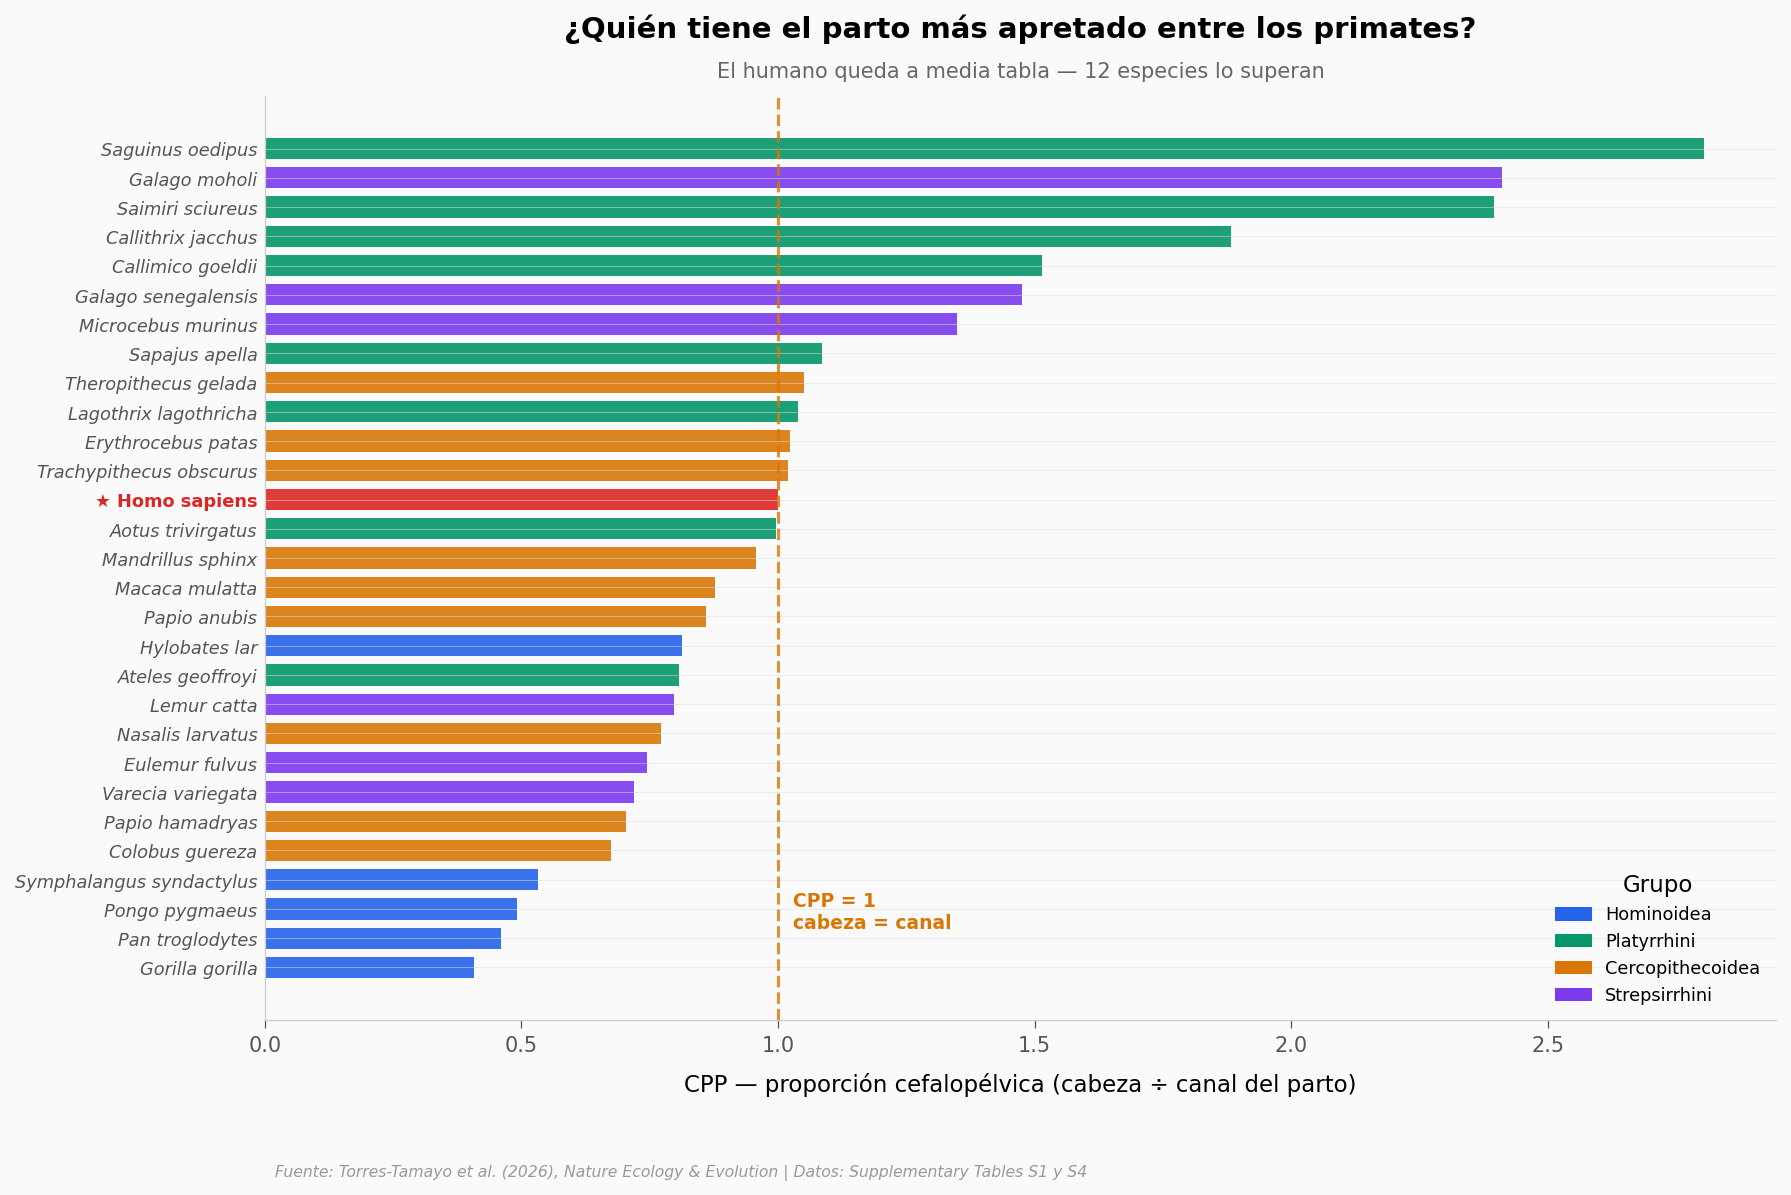

In [2]:
fig, ax = plt.subplots(figsize=(13, 8))

orden = cpp.sort_values('cpp_sinciput', ascending=True).reset_index(drop=True)
colores = [COLOR_FOCO if e == ESPECIE_FOCO else COLOR_GRUPO[g]
           for e, g in zip(orden['especie'], orden['grupo'])]
y = np.arange(len(orden))
ax.barh(y, orden['cpp_sinciput'], color=colores, alpha=0.9, height=0.72)

ax.set_yticks(y)
etiquetas = [e if e != ESPECIE_FOCO else f'★ {e}' for e in orden['especie']]
ax.set_yticklabels(etiquetas, fontsize=8.5, fontstyle='italic')
# Resaltar la etiqueta del humano
for tick, e in zip(ax.get_yticklabels(), orden['especie']):
    if e == ESPECIE_FOCO:
        tick.set_fontweight('bold')
        tick.set_color(COLOR_FOCO)
        tick.set_fontstyle('normal')

# Línea de umbral CPP=1
ax.axvline(UMBRAL_CPP, color=COLOR_UMBRAL, linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(UMBRAL_CPP + 0.03, 1.2, 'CPP = 1\ncabeza = canal',
        color=COLOR_UMBRAL, fontsize=9, fontweight='bold', va='bottom')

ax.set_xlabel('CPP — proporción cefalopélvica (cabeza ÷ canal del parto)', fontsize=11)
ax.set_title('¿Quién tiene el parto más apretado entre los primates?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.02, 'El humano queda a media tabla — 12 especies lo superan',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Leyenda de grupos (inline, esquina inferior derecha)
from matplotlib.patches import Patch
handles = [Patch(color=c, label=g) for g, c in COLOR_GRUPO.items()]
ax.legend(handles=handles, fontsize=8.5, loc='lower right', framealpha=0.9, title='Grupo')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ranking_cpp.png', dpi=200, bbox_inches='tight')
plt.show()

El humano aparece justo en el umbral, con un CPP de 1,00: la cabeza del bebé mide casi exactamente lo mismo que la entrada de la pelvis. Ajustado, sin duda. Pero por encima de él hay doce especies, y no son las que uno esperaría: tamarinos, gálagos, monos ardilla. El más apretado de todos, el tamarino de cabeza de algodón, llega a un CPP de 2,80 — su recién nacido casi triplica en área la entrada de su canal del parto.

La lista de "partos difíciles" no la encabeza el primate de cerebro grande. La encabezan los pequeños.

## ¿Qué significa realmente "apretado"?

CPP es un cociente entre dos áreas. Vale la pena verlo en su forma cruda: el área de la cabeza contra el área del canal, especie por especie.

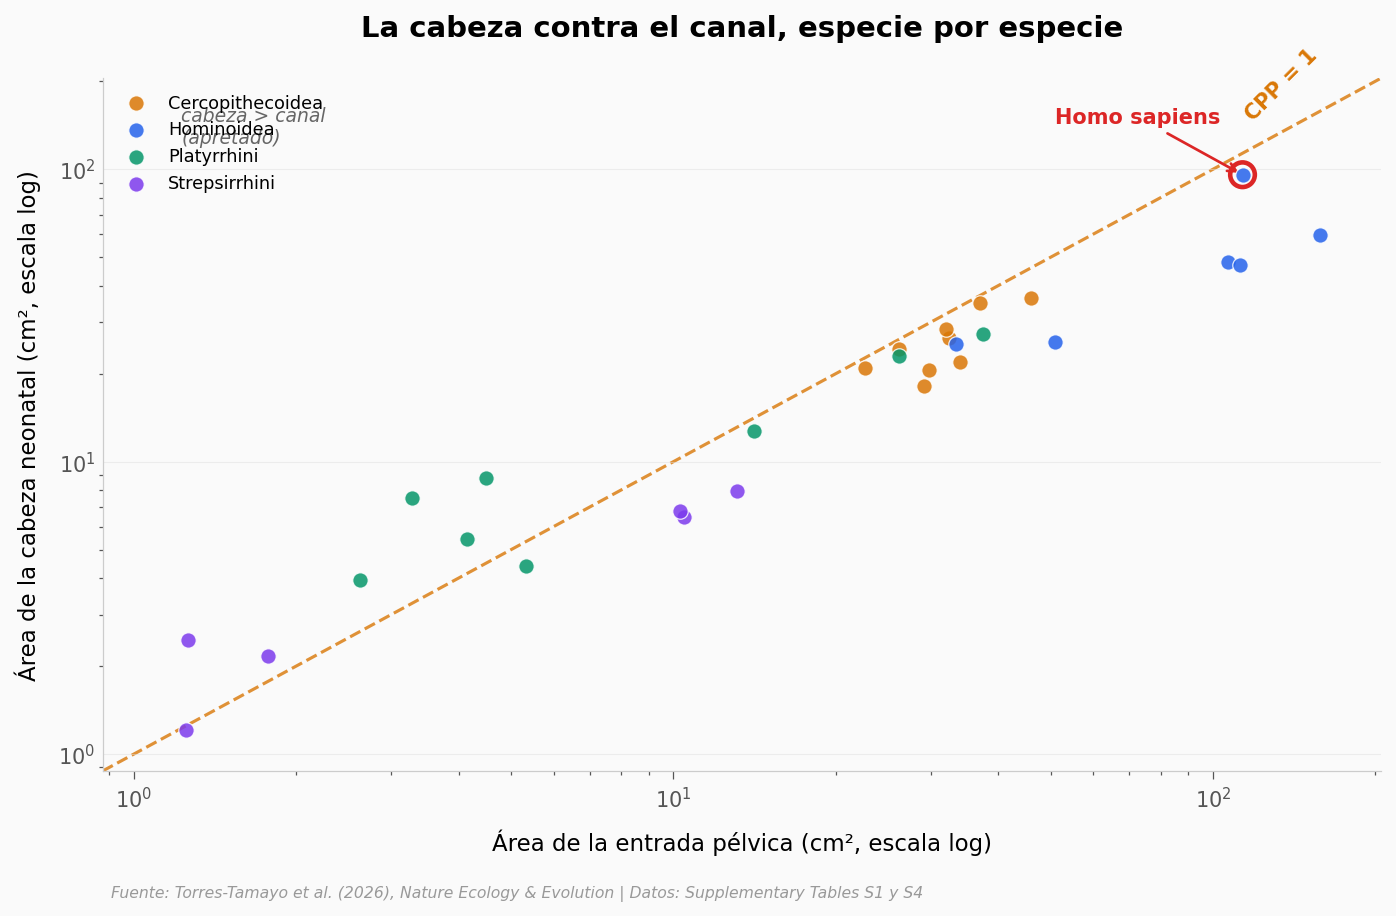

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))

for g, sub in cpp.groupby('grupo'):
    ax.scatter(sub['inlet_area_cm2'], sub['sinciput_head_area_cm2'],
               color=COLOR_GRUPO[g], s=55, alpha=0.85,
               edgecolors='white', linewidths=0.6, zorder=5, label=g)

# Diagonal CPP=1: cabeza = canal
lims = [cpp['inlet_area_cm2'].min() * 0.7, cpp['inlet_area_cm2'].max() * 1.3]
ax.plot(lims, lims, color=COLOR_UMBRAL, linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.text(lims[1] * 0.55, lims[1] * 0.72, 'CPP = 1', color=COLOR_UMBRAL,
        fontsize=10, fontweight='bold', rotation=45)
ax.text(lims[0] * 1.4, lims[1] * 0.6, 'cabeza > canal\n(apretado)', color='#666666',
        fontsize=9, style='italic')

# Marcar humano
h = cpp[cpp['especie'] == ESPECIE_FOCO].iloc[0]
ax.scatter(h['inlet_area_cm2'], h['sinciput_head_area_cm2'], s=140,
           facecolors='none', edgecolors=COLOR_FOCO, linewidths=2.2, zorder=6)
ax.annotate('Homo sapiens', xy=(h['inlet_area_cm2'], h['sinciput_head_area_cm2']),
            xytext=(h['inlet_area_cm2'] * 0.45, h['sinciput_head_area_cm2'] * 1.5),
            fontsize=10, fontweight='bold', color=COLOR_FOCO,
            arrowprops=dict(arrowstyle='->', color=COLOR_FOCO, lw=1.3))

ax.set_xlabel('Área de la entrada pélvica (cm², escala log)', fontsize=11)
ax.set_ylabel('Área de la cabeza neonatal (cm², escala log)', fontsize=11)
ax.set_title('La cabeza contra el canal, especie por especie',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=8.5, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cabeza_vs_canal.png', dpi=200, bbox_inches='tight')
plt.show()

Todo lo que quede por encima de la diagonal tiene una cabeza más grande que su canal. Ahí es donde el parto se complica.

Ahora bien: si el humano queda a media tabla, ¿de dónde salió la fama? De mirar solo a la familia de al lado.

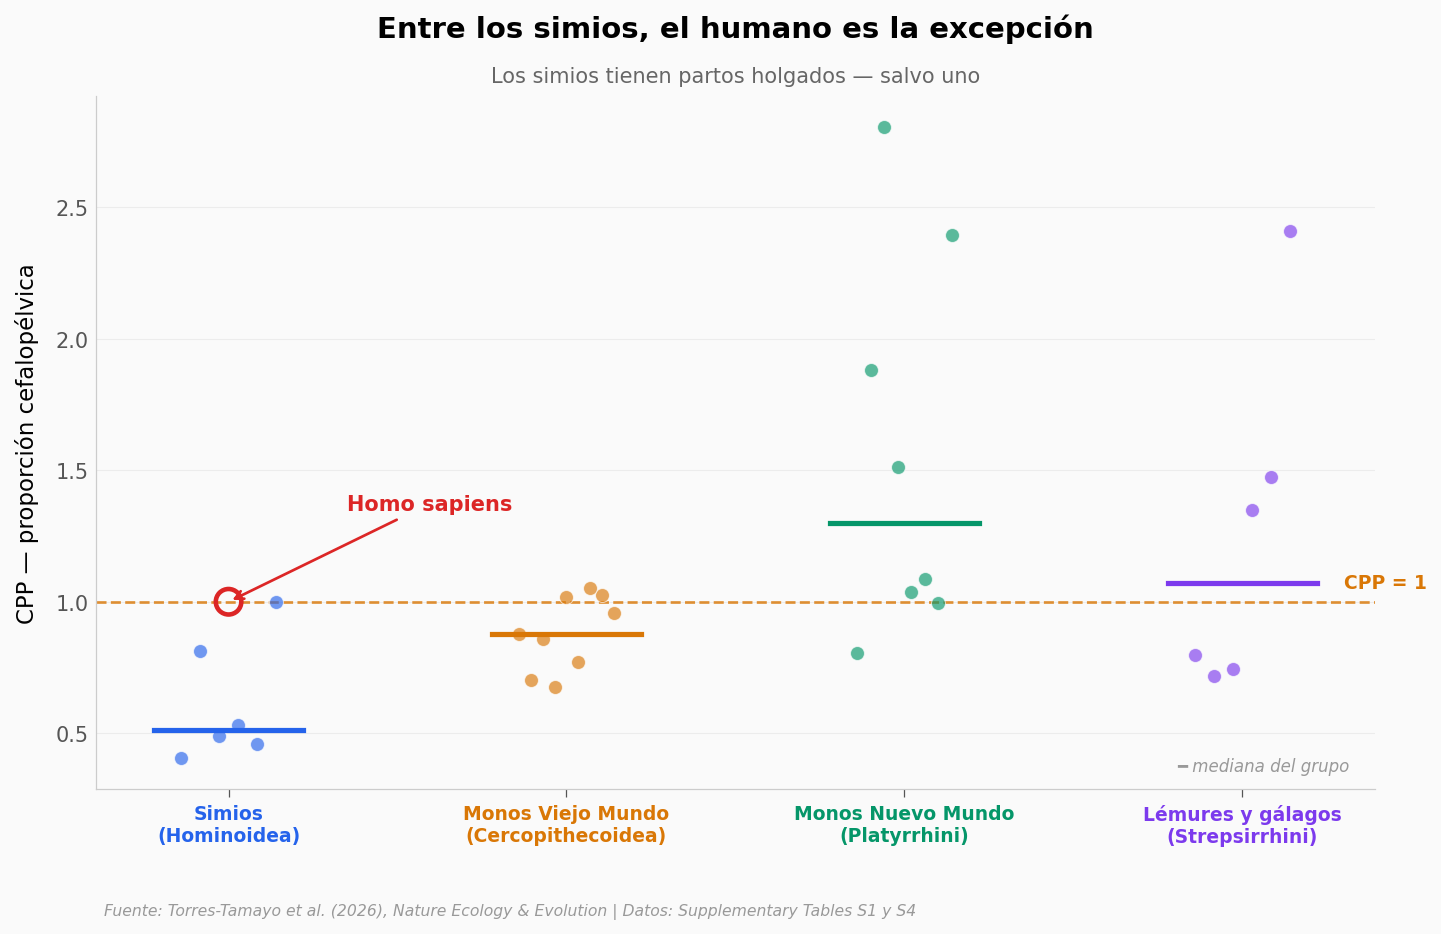

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))

orden_grupos = ['Hominoidea', 'Cercopithecoidea', 'Platyrrhini', 'Strepsirrhini']
np.random.seed(42)
for i, g in enumerate(orden_grupos):
    vals = cpp.loc[cpp['grupo'] == g, 'cpp_sinciput'].values
    n = len(vals)
    x_strip = np.linspace(i - 0.14, i + 0.14, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=COLOR_GRUPO[g], s=45, alpha=0.65,
               edgecolors='white', linewidths=0.5, zorder=5)
    med = np.median(vals)
    ax.plot([i - 0.22, i + 0.22], [med, med], color=COLOR_GRUPO[g],
            linewidth=2.5, zorder=6)

# Umbral CPP=1
ax.axhline(UMBRAL_CPP, color=COLOR_UMBRAL, linewidth=1.3, linestyle='--', alpha=0.8)
ax.text(3.3, UMBRAL_CPP + 0.05, 'CPP = 1', color=COLOR_UMBRAL, fontsize=9, fontweight='bold')

# Resaltar humano dentro de Hominoidea
ax.scatter([0], [homo], s=150, facecolors='none', edgecolors=COLOR_FOCO,
           linewidths=2.2, zorder=7)
ax.annotate('Homo sapiens', xy=(0, homo), xytext=(0.35, homo + 0.35),
            fontsize=10, fontweight='bold', color=COLOR_FOCO,
            arrowprops=dict(arrowstyle='->', color=COLOR_FOCO, lw=1.3))

ax.set_xticks(range(len(orden_grupos)))
etiquetas_g = ['Simios\n(Hominoidea)', 'Monos Viejo Mundo\n(Cercopithecoidea)',
               'Monos Nuevo Mundo\n(Platyrrhini)', 'Lémures y gálagos\n(Strepsirrhini)']
ax.set_xticklabels(etiquetas_g, fontsize=9)
for tick, g in zip(ax.get_xticklabels(), orden_grupos):
    tick.set_color(COLOR_GRUPO[g])
    tick.set_fontweight('bold')

ax.set_ylabel('CPP — proporción cefalopélvica', fontsize=11)
ax.set_title('Entre los simios, el humano es la excepción',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.02, 'Los simios tienen partos holgados — salvo uno',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ mediana del grupo', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cpp_por_grupo.png', dpi=200, bbox_inches='tight')
plt.show()

La mediana de los simios está en 0,51: sus bebés pasan con holgura. El humano, en 1,00, es un caso raro dentro de su propia familia. Los monos del Nuevo Mundo, en cambio, rondan el 1,30 de mediana — el parto apretado es su norma, no su excepción.

¿Qué separa a los apretados de los holgados? El paper apunta a una variable: el **tamaño de la madre**.

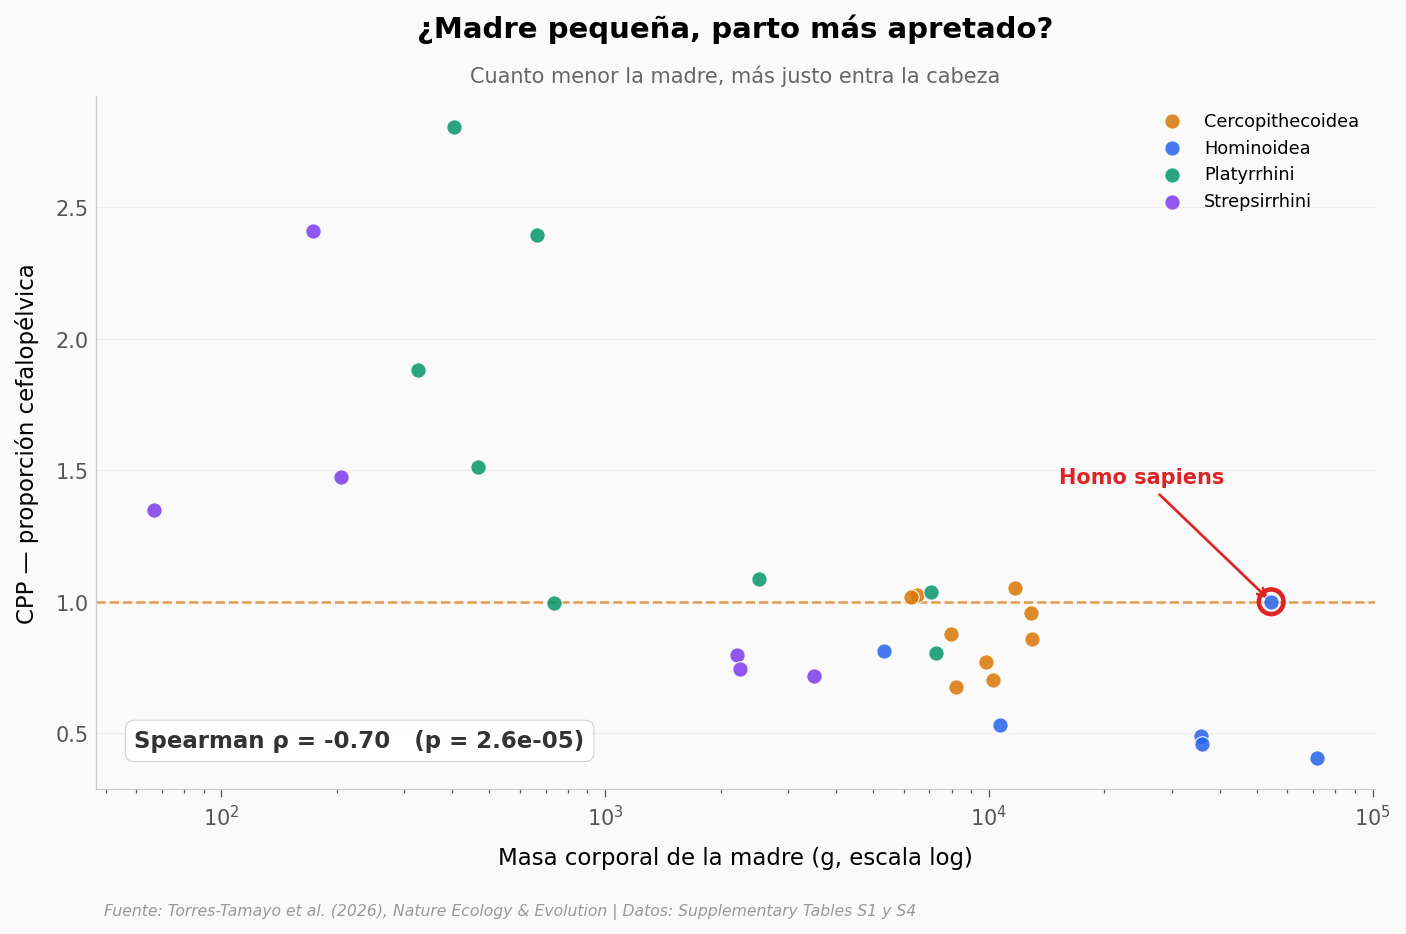

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

for g, sub in bm.groupby('grupo'):
    ax.scatter(sub['female_body_mass_g'], sub['cpp_sinciput'],
               color=COLOR_GRUPO[g], s=55, alpha=0.85,
               edgecolors='white', linewidths=0.6, zorder=5, label=g)
ax.set_xscale('log')

# Correlación de Spearman (CPP no es normal → rango, no Pearson)
rho, p = stats.spearmanr(bm['female_body_mass_g'], bm['cpp_sinciput'])

ax.axhline(UMBRAL_CPP, color=COLOR_UMBRAL, linewidth=1.2, linestyle='--', alpha=0.7)

# Marcar humano
hb = bm[bm['especie'] == ESPECIE_FOCO].iloc[0]
ax.scatter(hb['female_body_mass_g'], hb['cpp_sinciput'], s=140,
           facecolors='none', edgecolors=COLOR_FOCO, linewidths=2.2, zorder=6)
ax.annotate('Homo sapiens', xy=(hb['female_body_mass_g'], hb['cpp_sinciput']),
            xytext=(hb['female_body_mass_g'] * 0.28, hb['cpp_sinciput'] + 0.45),
            fontsize=10, fontweight='bold', color=COLOR_FOCO,
            arrowprops=dict(arrowstyle='->', color=COLOR_FOCO, lw=1.3))

ax.text(0.03, 0.06, f'Spearman ρ = {rho:.2f}   (p = {p:.1e})',
        transform=ax.transAxes, fontsize=11, fontweight='bold', color='#333333',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#CCCCCC', alpha=0.9))

ax.set_xlabel('Masa corporal de la madre (g, escala log)', fontsize=11)
ax.set_ylabel('CPP — proporción cefalopélvica', fontsize=11)
ax.set_title('¿Madre pequeña, parto más apretado?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.02, 'Cuanto menor la madre, más justo entra la cabeza',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=8.5, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cpp_vs_masa.png', dpi=200, bbox_inches='tight')
plt.show()

La correlación es negativa y fuerte: a menor masa materna, encaje más apretado. Ojo con la palabra: es una **asociación**. El estudio es observacional — comparó especies tal como son, no manipuló nada — así que muestra que las dos cosas van juntas, no que una cause la otra.

Con esto en mano, volvamos al humano. ¿Qué tan extremo es su 1,00 dentro de todo el reparto?

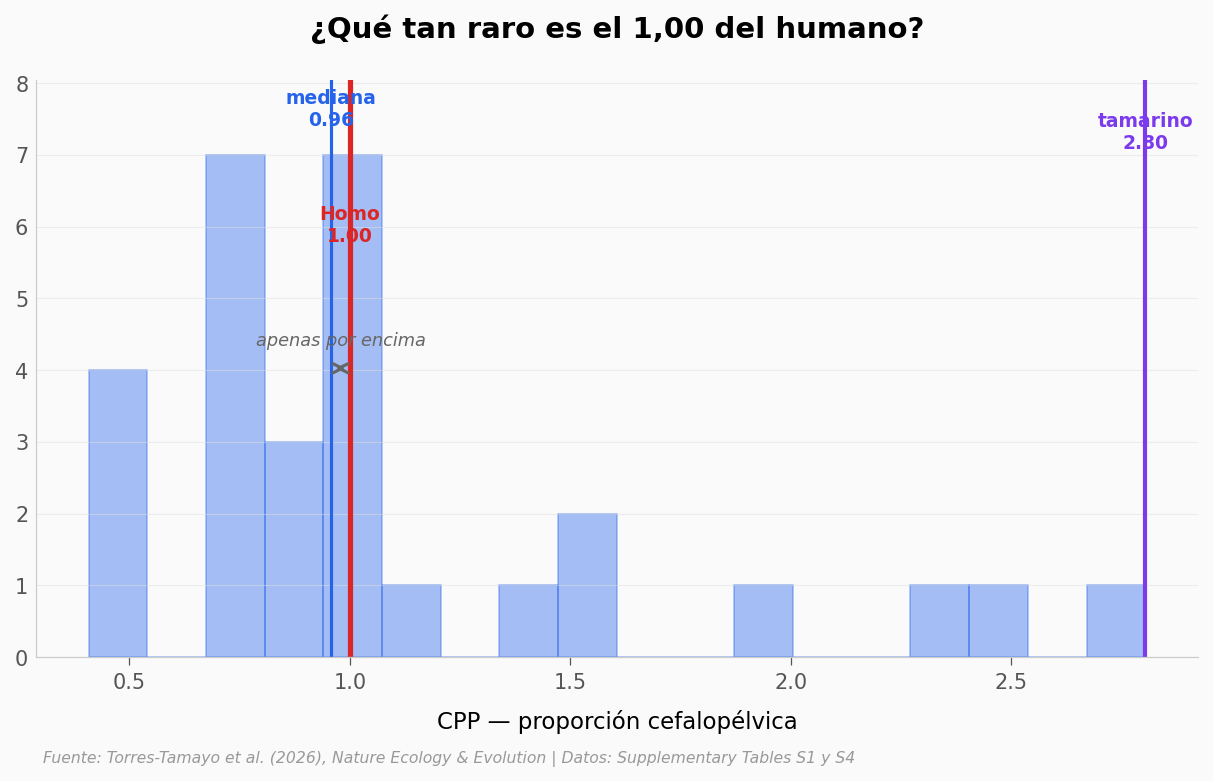

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

data = cpp['cpp_sinciput'].values
mediana = np.median(data)
n, bins, patches = ax.hist(data, bins=18, color='#2563EB', alpha=0.4,
                           edgecolor='#2563EB', linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

ax.axvline(mediana, color='#2563EB', linewidth=1.5)
ax.text(mediana, y_max * 0.92, f'mediana\n{mediana:.2f}', color='#2563EB',
        fontsize=9, ha='center', fontweight='bold')

ax.axvline(homo, color=COLOR_FOCO, linewidth=2.5)
ax.text(homo, y_max * 0.72, f'Homo\n{homo:.2f}', color=COLOR_FOCO,
        fontsize=9, ha='center', fontweight='bold')

cpp_max = data.max()
ax.axvline(cpp_max, color='#7C3AED', linewidth=2.0)
ax.text(cpp_max, y_max * 0.88, f'tamarino\n{cpp_max:.2f}', color='#7C3AED',
        fontsize=9, ha='center', fontweight='bold')

ax.annotate('', xy=(homo, y_max * 0.5), xytext=(mediana, y_max * 0.5),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((homo + mediana) / 2, y_max * 0.54, 'apenas por encima', color='#666666',
        fontsize=8.5, ha='center', style='italic')

ax.set_xlabel('CPP — proporción cefalopélvica', fontsize=11)
ax.set_title('¿Qué tan raro es el 1,00 del humano?',
             fontsize=14, fontweight='bold', pad=20)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_cpp.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El humano no tiene el parto más apretado del reino primate | ✅ | Puesto 13 de 29; 12 especies con CPP mayor. El más extremo es el tamarino (CPP 2,80) |
| El humano SÍ es el simio con el parto más apretado | ✅ | Homo 1,00 frente al siguiente simio, el gibón (0,81); gorila el más holgado (0,41) |
| A menor masa materna, encaje más apretado | ✅ (asociación) | Spearman ρ = -0,70 (p ≈ 3·10⁻⁵). Estudio observacional: correlación, no causa |
| La "unicidad" del parto humano sería un artefacto de medición | ⚠️ | El paper lo plantea como hipótesis que matiza la idea clásica (*may be an artefact*), no como veredicto cerrado |

> **Limitaciones:** Estudio comparativo/observacional — describe patrones entre especies, no prueba causas. Se usan medidas derivadas de las tablas suplementarias; los datos crudos de tomografía (CT) están restringidos. CPP es un cociente de áreas 2D del plano de entrada pélvico: una simplificación útil del parto, no su geometría completa. La correlación de Spearman se usa porque la distribución de CPP no es normal (Shapiro p < 0,001).

## Ahora tú

Los datos están cargados en `cpp` y `bm`. Tres preguntas para explorar:

1. **¿Cambia la historia si el bebé se presenta de cara en vez de con la coronilla (sinciput)?** El dataset trae `cpp_face`. ¿El humano sube o baja en el ranking? *Pista: `cpp.sort_values('cpp_face', ascending=False)`.*
2. **¿Qué grupo cruza más seguido el umbral CPP = 1?** *Pista: `cpp[cpp.cpp_sinciput > 1].grupo.value_counts()`.*
3. **¿Se mantiene la correlación solo entre los simios?** Filtra Hominoidea y vuelve a correr Spearman. Con 6 especies, ¿sigue siendo fiable? *Pista: `bm[bm.grupo == 'Hominoidea']`.*

In [7]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿qué grupo cruza más veces el umbral de parto apretado (CPP > 1)?
apretadas = cpp[cpp['cpp_sinciput'] > UMBRAL_CPP]
print(f'Especies con CPP > 1: {len(apretadas)} de {len(cpp)}\n')
print('Por grupo:')
print(apretadas['grupo'].value_counts().to_string())
print('\nLas 5 más apretadas:')
for _, r in apretadas.sort_values('cpp_sinciput', ascending=False).head(5).iterrows():
    print(f'  {r["especie"]:26s} ({r["grupo"]:16s})  CPP = {r["cpp_sinciput"]:.2f}')

Especies con CPP > 1: 12 de 29

Por grupo:
grupo
Platyrrhini         6
Cercopithecoidea    3
Strepsirrhini       3

Las 5 más apretadas:
  Saguinus oedipus           (Platyrrhini     )  CPP = 2.80
  Galago moholi              (Strepsirrhini   )  CPP = 2.41
  Saimiri sciureus           (Platyrrhini     )  CPP = 2.39
  Callithrix jacchus         (Platyrrhini     )  CPP = 1.88
  Callimico goeldii          (Platyrrhini     )  CPP = 1.51


## Fuentes

**Paper**: [Comparative primate analysis shows that humans are not unique in having a tight cephalopelvic fit at birth](https://doi.org/10.1038/s41559-026-03102-5)  
*Nature Ecology & Evolution, 2026-06-29*

**Supplementary Material**: [Tablas S1 y S4 — proporciones cefalopélvicas y masa corporal femenina](https://static-content.springer.com/esm/art%3A10.1038%2Fs41559-026-03102-5/MediaObjects/41559_2026_3102_MOESM2_ESM.xlsx)

**Código de réplica**: [OSF — scripts en R](https://osf.io/2yk8s/)

*11 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).*